In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import visualization.visualization as vis
import dl_embedding.vae as vae
from cuml.cluster import HDBSCAN

import torch
import numpy as np
from matplotlib import pyplot as plt


/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [3]:
#data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']
#data_channels_high_res = ['Salt','Theta','U','V','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']
data_channels_no_cor = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']

data_channels_engineered = ['gradb2','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']
dataset = cutouts_dataset.CutoutDataset.from_source(data_channels=data_channels_engineered, source=source, subset=False,
                                                    subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45345 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:34739' processes=4 threads=32, memory=128.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/45345/status
dropped 0 ice, 0 NaN; kept 3250 / 3250
features ['gradb2', 'gradrho2', 'turner_angle', 'strain_n', 'strain_s', 'strain_mag', 'divergence', 'relative_vorticity', 'oceQnet', 'ekman_pumping', 'wind_stress_curl'] | coords ['XC', 'YC']


2026-07-27 23:55:30,103 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-27 23:55:30,105 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-27 23:55:30,105 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-27 23:55:30,106 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing


In [4]:
# cutouts as VAE input (same preprocessing as DINO); patch_size fixed at 8 by the 3x stride-2 encoder
patch_size = 8
images = dataset.preprocess_for_training()   # (N, C, H, W): log-grads + z-score
print(images.shape)


(3250, 11, 64, 64)


In [5]:
# VAE embedding step: train on cutouts, embed = per-patch latent means
embedder = vae.ConvVAEEmbedder(latent_dim=16)
embedder.fit(images, epochs=30)
embeddings = embedder.embed(images)          # (N_patches, latent_dim), N_patches = N * (H/8)^2
print(embeddings.shape)


epoch 1/30  elbo 1.0009
epoch 2/30  elbo 0.9752
epoch 3/30  elbo 0.9342
epoch 4/30  elbo 0.9268
epoch 5/30  elbo 0.9217
epoch 6/30  elbo 0.9197
epoch 7/30  elbo 0.8994
epoch 8/30  elbo 0.8685
epoch 9/30  elbo 0.8440
epoch 10/30  elbo 0.8343
epoch 11/30  elbo 0.8276
epoch 12/30  elbo 0.8149
epoch 13/30  elbo 0.8104
epoch 14/30  elbo 0.8037
epoch 15/30  elbo 0.7922
epoch 16/30  elbo 0.7888
epoch 17/30  elbo 0.7799
epoch 18/30  elbo 0.7764
epoch 19/30  elbo 0.7739
epoch 20/30  elbo 0.7720
epoch 21/30  elbo 0.7701
epoch 22/30  elbo 0.7697
epoch 23/30  elbo 0.7602
epoch 24/30  elbo 0.7578
epoch 25/30  elbo 0.7559
epoch 26/30  elbo 0.7499
epoch 27/30  elbo 0.7509
epoch 28/30  elbo 0.7459
epoch 29/30  elbo 0.7398
epoch 30/30  elbo 0.7408
(208000, 16)


In [6]:
# Cluster the learned embeddings with cuML HDBSCAN
clusterer = HDBSCAN(min_cluster_size=5, min_samples=None)
clusters = np.asarray(clusterer.fit_predict(embeddings))   # (N_patches,); -1 = noise
print("clusters", int(clusters.max()) + 1,
      "| noise", int((clusters == -1).sum()), "/", clusters.size)


clusters 12 | noise 2580 / 208000


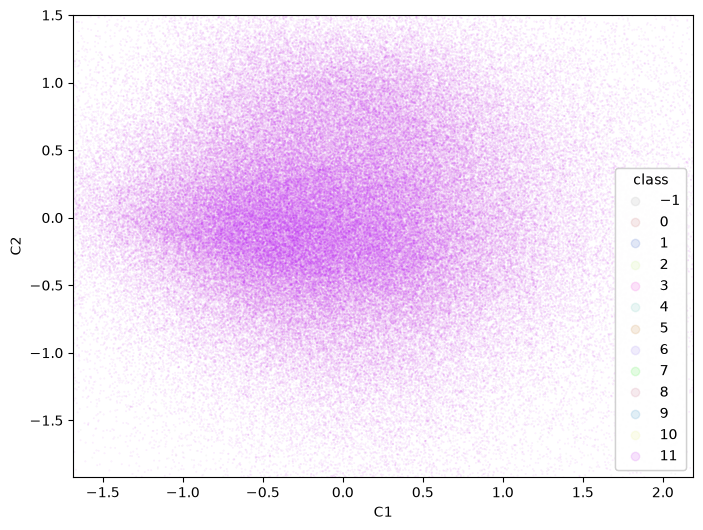

In [8]:
# 3D view of the clustering (PCA to 3D for display only)
from sklearn.decomposition import PCA
emb3 = PCA(n_components=2).fit_transform(embeddings)
vis.vis_dim_redux(emb3, labels=clusters, dims=2, alpha=0.1)


In [ ]:
np.unique(clusters)


In [ ]:
vis.plot_global_cluster_maps(dataset, clusters, patch_size=patch_size, alpha=0.1,
                             point_size=10.0, extent=None, coastlines=True,
                             panel_size=8, drop_noise=False, save_dir=None)


In [ ]:
vis.make_image_from_patches(dataset, clusters, patch_size=patch_size, number_rows=100)


In [10]:
# import torch

# model = torch.hub.load("insitro/ChannelViT",
#                        "imagenet_channelvit_small_p16_DINO", pretrained=True)

Using cache found in /home/jovyan/.cache/torch/hub/insitro_ChannelViT_main


ModuleNotFoundError: No module named 'torch._six'